
# RBP AFFINITY PREDICTION — WITH BINDING STRENGTH
Predicts RNA-Binding Protein (RBP) binding from genomic sequences using adual-head fine-tuned DistilBERT model with 5-mer tokenization.
For every input sequence the model outputs:
1. Binding label    — Binds (1) / Does Not Bind (0)
2. Binding strength — continuous score in [0, 1] derived from the signalValue regression head

Architecture:
DistilBERT backbone (shared weights)

       ├── Classification head  →  Binds / Does Not Bind
       └── Regression head      →  Predicted signalValue (binding strength)

Pipeline:
   1. Configuration
   2. Dependencies
   3. Data Preparation
   4. Sequence Extraction
   5. Model Definition (dual-head)
   6. Training
   7. Evaluation
   8. Inference helper
   9. Model Saving / Loading
 



# SECTION 1 - CONFIGURATION

In [91]:
import pandas as pd

In [92]:
narrow_peak_cols = [
    "chrom", "chromStart", "chromEnd", "name", "score", "strand",
    "signalValue", "pValue", "qValue", "peak",
    "sequence", "motif_starts", "motif_ends"
]
df = pd.read_csv("/kaggle/input/datasets/mandipsapkota/tdp38-hg19-assembly/with_motif.TARDBP.bed", sep='\t', header=None, names=narrow_peak_cols)
df.head()

,chrom,chromStart,chromEnd,name,score,strand,signalValue,pValue,qValue,peak,sequence,motif_starts,motif_ends
0,chr8,22057816,22057982,TARDBP_K562_IDRpeaks,1000,+,4.575056,11.879368,-1,-1,GAGCTACATCTCTGCCTTTACGCGTGACTTTGTATCCATGTCCAGG...,"'22057876','22057903','22057917','22057970','2...",NaN
1,chr9,138831213,138831451,TARDBP_K562_IDRpeaks,1000,-,5.701699,36.921158,-1,-1,GCTGTGGTGAGTGAGTGTGGGCTGTGGTGAGTGAGTGTGGGCTGTG...,"'138831437','138831417','138831401','138831361...",NaN
2,chr1,153788502,153788616,TARDBP_K562_IDRpeaks,1000,-,3.521126,4.414106,-1,-1,TTCTTTACAGCTGTTTGGGAGCAACATGTTAGAAGCGGAGTGTGTG...,"'153788577','153788571','153788565','153788559...",NaN
3,chr16,81712629,81712742,TARDBP_K562_IDRpeaks,1000,+,6.069640,18.340896,-1,-1,TGGATACATCTGCCAGGGTGTGCAGGAGCACAGGGGTGCCCAAGTG...,"'81712647','81712673','81712685','81712711','8...",NaN
4,chr16,81712554,81712679,TARDBP_K562_IDRpeaks,1000,+,5.387996,20.916497,-1,-1,CACATGTGCAAGGTGCATGCCCAAGCATACATGTGTACATATGTCT...,"'81712611','81712617','81712647','81712673','8...",NaN


In [93]:
RBP_FILE     = df   # CSV of RBP ChIP/CLIP-seq peaks (must contain signalValue)
GTF_FILE     = "/kaggle/input/datasets/mandipsapkota/gencode-v19-gtf/gencode.v19.annotation.gtf_withproteinids"   # GTF genome annotation file
GENOME_FASTA = "/kaggle/input/datasets/mandipsapkota/hg19-fasta/hg19.fa"   # Reference genome FASTA (e.g. hg38.fa)

# ── Sampling & filtering ──────────────────────────────────────────────────────
SIGNAL_THRESHOLD         = 3       # Minimum signalValue to treat peak as positive
N_NEGATIVES_PER_POSITIVE = 3       # Negatives sampled per positive peak
MAX_EXON_LENGTH          = 10000  # (bp) Upper bound for exon length filter
MIN_EXON_LENGTH          = 20      # (bp) Lower bound for exon length filter

# ── Training ──────────────────────────────────────────────────────────────────
TRAIN_CHROMOSOMES  = ["chr1", "chr2", "chr3"]  # Chromosomes used for train/val
TEST_CHROMOSOME    = "chr20"                   # Held-out chromosome for OOD eval
TRAIN_SPLIT        = 0.7
RANDOM_STATE       = 42
NUM_EPOCHS         = 6
BATCH_SIZE         = 20
LEARNING_RATE      = 5e-5
# Loss weighting: total_loss = cls_loss + LAMBDA_REG * reg_loss
LAMBDA_REG         = 0.5

# ── Paths ─────────────────────────────────────────────────────────────────────
SEQ_OUTPUT     = "/kaggle/working/all_regions_with_sequences.csv"
MODEL_SAVE_PATH = "./tdp43AffinityModel"



In [94]:
LOCAL_FASTA     = "/kaggle/working/hg38.fa"

# SECTION 2 - DEPENDENCIES

In [95]:
! pip install pysam BioSeq pyranges pyraidx Bio

In [96]:

import os
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pysam
import pyranges as pr
from Bio.Seq import Seq

# Suppress TensorFlow conflicts
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertModel,
    DistilBertTokenizerFast,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
)
from scipy.special import softmax
from scipy.stats import pearsonr

print("All dependencies loaded.")


All dependencies loaded.


## Block 4 - Load and filter rbp peaks

In [97]:
rbp.columns

Index(['Chromosome', 'Start', 'End', 'name', 'score', 'Strand', 'SignalValue',
       'pValue', 'qValue', 'peak', 'Sequence', 'motif_starts', 'motif_ends'],
      dtype='object')

In [98]:
rbp = pd.read_csv("/kaggle/input/datasets/mandipsapkota/tdp38-hg19-assembly/with_motif.TARDBP.bed", sep='\t', header=None, names=narrow_peak_cols)
rbp = rbp.rename(columns={
    "chrom"  : "Chromosome",
    "chromStart"  : "Start",
    "chromEnd"    : "End",
    "strand" : "Strand",
    "signalValue" : "SignalValue",
    "sequence"    : "Sequence",
})
rbp_final = rbp[rbp["SignalValue"] > SIGNAL_THRESHOLD][
    ["Chromosome", "Start", "End", "Strand", "SignalValue"]
].copy()

print(f"Total peaks loaded    : {len(rbp):,}")
print(f"High-confidence peaks : {len(rbp_final):,}")
print(rbp_final.head())

Total peaks loaded    : 6,827
High-confidence peaks : 6,827
  Chromosome      Start        End Strand  SignalValue
0       chr8   22057816   22057982      +     4.575056
1       chr9  138831213  138831451      -     5.701699
2       chr1  153788502  153788616      -     3.521126
3      chr16   81712629   81712742      +     6.069640
4      chr16   81712554   81712679      +     5.387996


# BLOCK 5 - LOAD & FILTER EXONS FROM GTF

In [99]:
    
GTF_COLS = ["Chromosome", "Source", "Feature", "Start", "End",
            "Score", "Strand", "Frame", "Attribute"]

gtf = pd.read_csv(GTF_FILE, sep="\t", header=None, comment="#", names=GTF_COLS)

exon_len = gtf["End"] - gtf["Start"]

exons = gtf[
    (gtf["Feature"] == "exon") &
    (exon_len >= MIN_EXON_LENGTH) &
    (exon_len <= MAX_EXON_LENGTH)
][["Chromosome", "Start", "End", "Strand"]].copy()

exons["Strand"] = exons["Strand"].astype(str)

print(f"Total GTF records : {len(gtf):,}")
print(f"Filtered exons    : {len(exons):,}")

Total GTF records : 2,619,444
Filtered exons    : 1,188,772


# BLOCK 6 — BUILD POSITIVE REGIONS

In [100]:
# Positives are RBP peaks that overlap an exon.
# PyRanges performs the vectorised genomic overlap join.
# The original signalValue is re-attached after the join via a coordinate merge
# because PyRanges may reorder rows.

rbp_pr   = pr.PyRanges(rbp_final[["Chromosome", "Start", "End", "Strand"]])
exons_pr = pr.PyRanges(exons)

positives_pr = rbp_pr.join(exons_pr)
positives_df = positives_pr.df[["Chromosome", "Start", "End", "Strand"]].copy()
positives_df["Strand"] = positives_df["Strand"].astype(str)

positives_df = positives_df.merge(
    rbp_final[["Chromosome", "Start", "End", "Strand", "SignalValue"]],
    on=["Chromosome", "Start", "End", "Strand"],
    how="left",
).rename(columns={"SignalValue": "SignalValue"})

positives_df["Label"] = 1

print(f"Positive regions          : {len(positives_df):,}")
print("SignalValue summary:")
print(positives_df["SignalValue"].describe().round(3))


Positive regions          : 3,848
SignalValue summary:
count    3848.000
mean        4.391
std         0.935
min         3.000
25%         3.674
50%         4.255
75%         4.909
max         8.134
Name: SignalValue, dtype: float64


# BLOCK 6 — BUILD POSITIVE REGIONS
Positives = RBP peaks that overlap an exon.
PyRanges performs the vectorised genomic overlap join.
SignalValue and Sequence are re-attached after the join via coordinate merge since PyRanges may reorder rows.

In [101]:
rbp_pr   = pr.PyRanges(rbp_final[["Chromosome", "Start", "End", "Strand"]])
exons_pr = pr.PyRanges(exons)

positives_pr = rbp_pr.join(exons_pr)
positives_df = positives_pr.df[["Chromosome", "Start", "End", "Strand"]].copy()
positives_df["Strand"] = positives_df["Strand"].astype(str)

# Build merge columns dynamically — include Sequence only if it exists in rbp_final
# Some BED files don't have a sequence column; sequences will be extracted from
# FASTA in Block 10 for those rows instead.
merge_cols = ["Chromosome", "Start", "End", "Strand", "SignalValue"]
if "Sequence" in rbp_final.columns:
    merge_cols.append("Sequence")
else:
    print("No 'Sequence' column found in rbp_final — sequences will be fetched from FASTA.")
    positives_df["Sequence"] = None

positives_df = positives_df.merge(
    rbp_final[merge_cols],
    on=["Chromosome", "Start", "End", "Strand"],
    how="left",
)

positives_df["Label"] = 1

print(f"Positive regions : {len(positives_df):,}")
print("SignalValue summary:")
print(positives_df["SignalValue"].describe().round(3))


No 'Sequence' column found in rbp_final — sequences will be fetched from FASTA.
Positive regions : 3,848
SignalValue summary:
count    3848.000
mean        4.391
std         0.935
min         3.000
25%         3.674
50%         4.255
75%         4.909
max         8.134
Name: SignalValue, dtype: float64


# BLOCK 7 — BUILD NEGATIVE CANDIDATE POOL

In [102]:
pr_exons     = pr.PyRanges(exons)
pr_positives = pr.PyRanges(positives_df[["Chromosome", "Start", "End", "Strand"]])

candidate_df = pr_exons.subtract(pr_positives).as_df()

print(f"Candidate negative exons : {len(candidate_df):,}")

Candidate negative exons : 1,190,121


# BLOCK 8 — SAMPLE NEGATIVES

In [103]:

negatives_list = []
negatives_set  = set()

for _, pos in positives_df.iterrows():
    pos_len = pos["End"] - pos["Start"]

    chrom_exons = candidate_df[
        (candidate_df["Chromosome"] == pos["Chromosome"]) &
        (candidate_df["Strand"]     == pos["Strand"])
    ].copy()

    if chrom_exons.empty:
        continue

    sampled, attempts = 0, 0

    while sampled < N_NEGATIVES_PER_POSITIVE and attempts < 50:
        exon     = chrom_exons.sample(1).iloc[0]
        exon_len = exon["End"] - exon["Start"]

        if exon_len < pos_len:
            attempts += 1
            continue

        start = random.randint(exon["Start"], exon["End"] - pos_len)
        end   = start + pos_len
        key   = (exon["Chromosome"], start, end, exon["Strand"])

        if key not in negatives_set:
            negatives_list.append(key)
            negatives_set.add(key)
            sampled += 1

        attempts += 1

negatives_df = pd.DataFrame(
    negatives_list, columns=["Chromosome", "Start", "End", "Strand"]
)
negatives_df["Label"]       = 0
negatives_df["SignalValue"] = 0.0    # no binding → strength = 0
negatives_df["Sequence"]    = None   # filled in Block 10

print(f"Negative regions     : {len(negatives_df):,}")
print(f"Neg / Pos ratio      : {len(negatives_df)/len(positives_df):.2f}")



Negative regions     : 11,544
Neg / Pos ratio      : 3.00


# BLOCK 9 — MERGE POSITIVES AND NEGATIVES

In [104]:

all_regions = pd.concat([positives_df, negatives_df], ignore_index=True)

print(f"Total regions   : {len(all_regions):,}")
print(f"  Positives (1) : {(all_regions['Label']==1).sum():,}")
print(f"  Negatives (0) : {(all_regions['Label']==0).sum():,}")
print(all_regions.head())

Total regions   : 15,392
  Positives (1) : 3,848
  Negatives (0) : 11,544
  Chromosome      Start        End Strand Sequence  SignalValue  Label
0       chr1  109642874  109642932      +     None     6.345574      1
1       chr1  109642874  109642932      +     None     6.345574      1
2       chr1  203775063  203775202      +     None     4.723257      1
3       chr1    8031992    8032112      +     None     4.758091      1
4       chr1  198725514  198725641      +     None     5.668865      1


# BLOCK 10 — FILL SEQUENCES

In [105]:

if not os.path.exists(LOCAL_FASTA):
    print(f"Copying FASTA to {LOCAL_FASTA} ...")
    shutil.copy(GENOME_FASTA, LOCAL_FASTA)

fasta = pysam.FastaFile(LOCAL_FASTA)

# Only fetch sequences for rows where Sequence is missing (i.e. negatives)
neg_mask = all_regions["Sequence"].isna()
print(f"Fetching sequences for {neg_mask.sum():,} negative regions ...")

for idx, row in all_regions[neg_mask].iterrows():
    seq = fasta.fetch(row["Chromosome"], row["Start"], row["End"])
    if row["Strand"] == "-":
        seq = str(Seq(seq).reverse_complement())
    all_regions.at[idx, "Sequence"] = seq

all_regions.to_csv(SEQ_OUTPUT, index=False)
print(f"All sequences saved → {SEQ_OUTPUT}")
print(all_regions[["Chromosome", "Start", "End", "Label", "SignalValue", "Sequence"]].head())


Fetching sequences for 15,392 negative regions ...
All sequences saved → /kaggle/working/all_regions_with_sequences.csv
  Chromosome      Start        End  Label  SignalValue  \
0       chr1  109642874  109642932      1     6.345574   
1       chr1  109642874  109642932      1     6.345574   
2       chr1  203775063  203775202      1     4.723257   
3       chr1    8031992    8032112      1     4.758091   
4       chr1  198725514  198725641      1     5.668865   

                                            Sequence  
0  TGTGAGGCGCGTGCAGGGTGAGTGTGAGTGGACGCGTGAGTGTGTG...  
1  TGTGAGGCGCGTGCAGGGTGAGTGTGAGTGGACGCGTGAGTGTGTG...  
2  CCCAGTTTCATAGCATCAACCGTGGTCTTGGTATCCTTCAATGACT...  
3  CAAAAAAAAAATAAAATAAAATAAAATAAATATTTGTCAGAAGAGT...  
4  ATTTTATCTCTTATTCAGTAAAAAACAACTTCTTTGTAATCGTTAT...  


# BLOCK 11 — 5-MER TOKENISATION & TRAIN/TEST SPLIT

In [106]:

df    = pd.read_csv(SEQ_OUTPUT)
df_tv = df[df["Chromosome"].isin(TRAIN_CHROMOSOMES)].copy()

print(f"Train/val pool : {len(df_tv):,} regions")

X_train_raw, X_test_raw, y_train, y_test, sv_train, sv_test = train_test_split(
    df_tv["Sequence"].tolist(),
    df_tv["Label"].tolist(),
    df_tv["SignalValue"].tolist(),
    train_size=TRAIN_SPLIT,
    random_state=RANDOM_STATE,
)

train_5mers = [" ".join(s[i:i+2] for i in range(len(s)-1)) for s in X_train_raw]
test_5mers  = [" ".join(s[i:i+2] for i in range(len(s)-1)) for s in X_test_raw]

print(f"Train : {len(train_5mers):,}  |  Test : {len(test_5mers):,}")
print(f"Example 5-mer : {train_5mers[0][:60]} ...")

Train/val pool : 3,872 regions
Train : 2,710  |  Test : 1,162
Example 5-mer : CT TG GG GT TC CC CA AA AA AG GC CG GC CC CA AC CG GA AT TC  ...


# BLOCK 12 — TOKENIZE WITH DISTILBERT TOKENIZER

In [107]:

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Check actual sequence lengths before tokenising so we can pick a safe max_length
sample_lengths = [len(tokenizer.tokenize(s)) for s in train_5mers[:500]]
p95_len        = int(np.percentile(sample_lengths, 95))
MAX_LEN        = min(p95_len + 10, 512)   # cap at 512 (DistilBERT hard limit)

print(f"Token length stats (sample of 500):")
print(f"  Min    : {min(sample_lengths)}")
print(f"  Median : {int(np.median(sample_lengths))}")
print(f"  95th % : {p95_len}")
print(f"  Max    : {max(sample_lengths)}")
print(f"  → Using max_length = {MAX_LEN}")

# padding='max_length' + explicit max_length keeps all tensors the same fixed
# size without bloating to the longest sequence in the whole dataset
train_enc = tokenizer(train_5mers, padding="max_length", truncation=True, max_length=MAX_LEN)
test_enc  = tokenizer(test_5mers,  padding="max_length", truncation=True, max_length=MAX_LEN)

print("Tokenisation complete.")
print(f"Encoding keys : {list(train_enc.keys())}")

Token length stats (sample of 500):
  Min    : 60
  Median : 150
  95th % : 217
  Max    : 383
  → Using max_length = 227
Tokenisation complete.
Encoding keys : ['input_ids', 'attention_mask']


# BLOCK 13 — BUILD PYTORCH DATASETS

In [108]:

class DNADataset(Dataset):
    def __init__(self, encodings, labels, signal_values):
        self.encodings     = encodings
        self.labels        = labels
        self.signal_values = signal_values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"]        = torch.tensor(self.labels[idx],        dtype=torch.long)
        item["signal_values"] = torch.tensor(self.signal_values[idx], dtype=torch.float)
        return item

train_ds = DNADataset(train_enc, y_train, sv_train)
test_ds  = DNADataset(test_enc,  y_test,  sv_test)

print(f"Train dataset : {len(train_ds):,}")
print(f"Test dataset  : {len(test_ds):,}")

Train dataset : 2,710
Test dataset  : 1,162


# BLOCK 14 — DEFINE DUAL-HEAD MODEL

In [109]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [110]:

class RBPDualHeadModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.backbone = DistilBertModel.from_pretrained("distilbert-base-uncased")
        hidden = self.backbone.config.hidden_size   # 768

        self.classification_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 2),
        )

        self.regression_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1),
            nn.ReLU(),              # signalValue >= 0
        )

    def forward(self, input_ids, attention_mask):
        out       = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = out.last_hidden_state[:, 0, :]
        return self.classification_head(cls_token), self.regression_head(cls_token)

model = RBPDualHeadModel().to(DEVICE)

print("Model built.")
print(f"Trainable parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model built.
Trainable parameters : 66,757,379


# BLOCK 15 — TRAINING SETUP

In [111]:

cls_criterion = nn.CrossEntropyLoss()
reg_criterion = nn.MSELoss()

optimizer    = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(test_ds,  batch_size=BATCH_SIZE)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = int(0.1 * total_steps),
    num_training_steps= total_steps,
)

print(f"Total training steps : {total_steps:,}")
print(f"Warmup steps         : {int(0.1 * total_steps):,}")

Total training steps : 816
Warmup steps         : 81


# BLOCK 16 — TRAINING LOOP

In [112]:

from tqdm.auto import tqdm
import time

best_val_auc   = 0.0
train_loss_log = []
val_auc_log    = []

total_batches = len(train_loader) * NUM_EPOCHS
print(f"Starting training — {NUM_EPOCHS} epochs  |  {len(train_loader)} batches/epoch  |  {total_batches} total steps")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # ── Training pass ──────────────────────────────────────────────────────────
    model.train()
    total_loss = cls_loss_sum = reg_loss_sum = 0.0

    # tqdm wraps the DataLoader and shows a live progress bar per epoch
    train_bar = tqdm(
        train_loader,
        desc        = f"Epoch {epoch}/{NUM_EPOCHS} [Train]",
        unit        = "batch",
        leave       = True,
        dynamic_ncols= True,
    )

    for step, batch in enumerate(train_bar, 1):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        signals        = batch["signal_values"].to(DEVICE)

        cls_logits, reg_output = model(input_ids, attention_mask)

        cls_loss = cls_criterion(cls_logits, labels)
        reg_loss = reg_criterion(reg_output.squeeze(), signals)
        loss     = cls_loss + LAMBDA_REG * reg_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item()
        cls_loss_sum  += cls_loss.item()
        reg_loss_sum  += reg_loss.item()

        # Update the progress bar with running average losses after every batch
        train_bar.set_postfix({
            "loss" : f"{total_loss/step:.4f}",
            "cls"  : f"{cls_loss_sum/step:.4f}",
            "reg"  : f"{reg_loss_sum/step:.4f}",
            "lr"   : f"{scheduler.get_last_lr()[0]:.2e}",
        })

    avg_total = total_loss   / len(train_loader)
    avg_cls   = cls_loss_sum / len(train_loader)
    avg_reg   = reg_loss_sum / len(train_loader)
    train_loss_log.append(avg_total)

    # ── Validation pass ────────────────────────────────────────────────────────
    model.eval()
    val_logits_all = []
    val_labels_all = []
    val_reg_all    = []
    val_sig_all    = []

    val_bar = tqdm(
        val_loader,
        desc        = f"Epoch {epoch}/{NUM_EPOCHS} [Val]  ",
        unit        = "batch",
        leave       = True,
        dynamic_ncols= True,
    )

    with torch.no_grad():
        for batch in val_bar:
            cls_logits, reg_out = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE),
            )
            val_logits_all.append(cls_logits.cpu().numpy())
            val_labels_all.append(batch["labels"].numpy())
            val_reg_all.append(reg_out.squeeze().cpu().numpy())
            val_sig_all.append(batch["signal_values"].numpy())

    val_logits_all = np.concatenate(val_logits_all)
    val_labels_all = np.concatenate(val_labels_all)
    val_reg_all    = np.concatenate(val_reg_all)
    val_sig_all    = np.concatenate(val_sig_all)

    val_probs  = softmax(val_logits_all, axis=1)[:, 1]
    val_preds  = np.argmax(val_logits_all, axis=1)
    val_auc    = roc_auc_score(val_labels_all, val_probs)
    val_acc    = accuracy_score(val_labels_all, val_preds)
    val_f1     = f1_score(val_labels_all, val_preds)
    val_mae    = np.mean(np.abs(val_reg_all - val_sig_all))
    epoch_time = time.time() - epoch_start

    val_auc_log.append(val_auc)

    # ── Epoch summary ──────────────────────────────────────────────────────────
    print(f"\n{'─'*70}")
    print(f"  Epoch {epoch}/{NUM_EPOCHS} summary  ({epoch_time:.1f}s)")
    print(f"{'─'*70}")
    print(f"  Train  │  loss={avg_total:.4f}  cls={avg_cls:.4f}  reg={avg_reg:.4f}")
    print(f"  Val    │  auc={val_auc:.4f}  acc={val_acc:.4f}  f1={val_f1:.4f}  strength_mae={val_mae:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        os.makedirs(MODEL_SAVE_PATH + "_best", exist_ok=True)
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_SAVE_PATH + "_best", "model_weights.pt")
        )
        print(f"  ✓ Best model saved  (val_auc={best_val_auc:.4f})")

    print(f"{'─'*70}\n")

print("=" * 70)
print(f"Training complete.  Best val_auc = {best_val_auc:.4f}")

Starting training — 6 epochs  |  136 batches/epoch  |  816 total steps


Epoch 1/6 [Train]:   0%|          | 0/136 [00:00<?, ?batch/s]

Epoch 1/6 [Val]  :   0%|          | 0/59 [00:00<?, ?batch/s]


──────────────────────────────────────────────────────────────────────
  Epoch 1/6 summary  (1395.2s)
──────────────────────────────────────────────────────────────────────
  Train  │  loss=1.5614  cls=0.3729  reg=2.3769
  Val    │  auc=0.9738  acc=0.9131  f1=0.8098  strength_mae=0.4702
  ✓ Best model saved  (val_auc=0.9738)
──────────────────────────────────────────────────────────────────────



Epoch 2/6 [Train]:   0%|          | 0/136 [00:00<?, ?batch/s]

...

Epoch 5/6 [Val]  :   0%|          | 0/59 [00:00<?, ?batch/s]


──────────────────────────────────────────────────────────────────────
  Epoch 5/6 summary  (1443.6s)
──────────────────────────────────────────────────────────────────────
  Train  │  loss=0.4184  cls=0.1141  reg=0.6087
  Val    │  auc=0.9912  acc=0.9578  f1=0.9216  strength_mae=0.3395
  ✓ Best model saved  (val_auc=0.9912)
──────────────────────────────────────────────────────────────────────



Epoch 6/6 [Train]:   0%|          | 0/136 [00:00<?, ?batch/s]

Epoch 6/6 [Val]  :   0%|          | 0/59 [00:00<?, ?batch/s]


──────────────────────────────────────────────────────────────────────
  Epoch 6/6 summary  (1428.8s)
──────────────────────────────────────────────────────────────────────
  Train  │  loss=0.3050  cls=0.0875  reg=0.4349
  Val    │  auc=0.9925  acc=0.9682  f1=0.9394  strength_mae=0.2889
  ✓ Best model saved  (val_auc=0.9925)
──────────────────────────────────────────────────────────────────────

Training complete.  Best val_auc = 0.9925


In [113]:
model

RBPDualHeadModel(
  (backbone): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

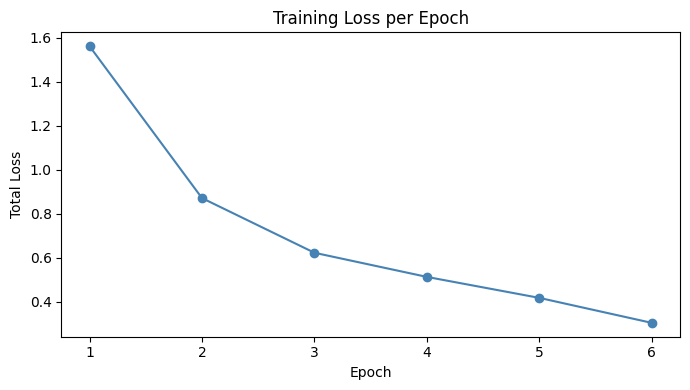

Loss plot saved.


In [114]:
## Training loss
plt.figure(figsize=(7, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_loss_log, marker="o", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss per Epoch")
plt.tight_layout()
plt.savefig("/kaggle/working/training_loss.png", dpi=150)
plt.show()
print("Loss plot saved.")

In [115]:
## in distribuition evalutaion
model.eval()
eval_logits  = []
eval_reg     = []
eval_labels  = []
eval_signals = []

with torch.no_grad():
    for batch in val_loader:
        cls_logits, reg_out = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )
        eval_logits.append(cls_logits.cpu().numpy())
        eval_reg.append(reg_out.squeeze().cpu().numpy())
        eval_labels.append(batch["labels"].numpy())
        eval_signals.append(batch["signal_values"].numpy())

eval_logits  = np.concatenate(eval_logits)
eval_reg     = np.concatenate(eval_reg)
eval_labels  = np.concatenate(eval_labels)
eval_signals = np.concatenate(eval_signals)

eval_preds = np.argmax(eval_logits, axis=1)
eval_probs = softmax(eval_logits, axis=1)[:, 1]

print("=" * 55)
print("IN-DISTRIBUTION EVALUATION  (chr1–3 test split)")
print("=" * 55)
print(classification_report(eval_labels, eval_preds,
                             target_names=["Does Not Bind", "Binds"]))
print(f"ROC-AUC   : {roc_auc_score(eval_labels, eval_probs):.4f}")

eval_mae       = np.mean(np.abs(eval_reg - eval_signals))
eval_r, eval_p = pearsonr(eval_reg, eval_signals)
print(f"\nBinding Strength Regression:")
print(f"  MAE       : {eval_mae:.4f}")
print(f"  Pearson r : {eval_r:.4f}  (p={eval_p:.4e})")

IN-DISTRIBUTION EVALUATION  (chr1–3 test split)
               precision    recall  f1-score   support

Does Not Bind       0.98      0.98      0.98       856
        Binds       0.94      0.94      0.94       306

     accuracy                           0.97      1162
    macro avg       0.96      0.96      0.96      1162
 weighted avg       0.97      0.97      0.97      1162

ROC-AUC   : 0.9925

Binding Strength Regression:
  MAE       : 0.2889
  Pearson r : 0.9208  (p=0.0000e+00)


In [ ]:
## out of distribuition
df_chr20     = df[df["Chromosome"] == TEST_CHROMOSOME].copy()
chr20_5mers  = [" ".join(s[i:i+5] for i in range(len(s)-4))
                for s in df_chr20["Sequence"].tolist()]
chr20_enc    = tokenizer(chr20_5mers, padding=True, truncation=True)
chr20_ds     = DNADataset(
    chr20_enc,
    df_chr20["Label"].tolist(),
    df_chr20["SignalValue"].tolist(),
)
chr20_loader = DataLoader(chr20_ds, batch_size=BATCH_SIZE)

model.eval()
chr20_logits  = []
chr20_reg     = []
chr20_labels  = []
chr20_signals = []

with torch.no_grad():
    for batch in chr20_loader:
        cls_logits, reg_out = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )
        chr20_logits.append(cls_logits.cpu().numpy())
        chr20_reg.append(reg_out.squeeze().cpu().numpy())
        chr20_labels.append(batch["labels"].numpy())
        chr20_signals.append(batch["signal_values"].numpy())

chr20_logits  = np.concatenate(chr20_logits)
chr20_reg     = np.concatenate(chr20_reg)
chr20_labels  = np.concatenate(chr20_labels)
chr20_signals = np.concatenate(chr20_signals)

chr20_preds = np.argmax(chr20_logits, axis=1)
chr20_probs = softmax(chr20_logits, axis=1)[:, 1]

print("=" * 55)
print(f"OUT-OF-DISTRIBUTION EVALUATION  ({TEST_CHROMOSOME})")
print("=" * 55)
print(classification_report(chr20_labels, chr20_preds,
                             target_names=["Does Not Bind", "Binds"]))
print(f"ROC-AUC   : {roc_auc_score(chr20_labels, chr20_probs):.4f}")

chr20_mae        = np.mean(np.abs(chr20_reg - chr20_signals))
chr20_r, chr20_p = pearsonr(chr20_reg, chr20_signals)
print(f"\nBinding Strength Regression:")
print(f"  MAE       : {chr20_mae:.4f}")
print(f"  Pearson r : {chr20_r:.4f}  (p={chr20_p:.4e})")

In [117]:
import torch
import os

save_directory = "./rbp_distilbert_model_new"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

# Save the weights
torch.save(model.state_dict(), os.path.join(save_directory, 'model_weights.pth'))

# Save the tokenizer (this part still works with .save_pretrained!)
tokenizer.save_pretrained(save_directory)

('./rbp_distilbert_model_new/tokenizer_config.json',
 './rbp_distilbert_model_new/tokenizer.json')

# Inference

In [119]:
import torch
import torch.nn as nn
from transformers import DistilBertModel, AutoTokenizer

class RBPDualHeadModel(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased"):
        super(RBPDualHeadModel, self).__init__()
        self.backbone = DistilBertModel.from_pretrained(model_name)
        
        self.classification_head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, 2)
        )
        
        self.regression_head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, 1),
            nn.ReLU()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # Using the [CLS] token (first token) for the heads
        last_hidden_state = outputs.last_hidden_state[:, 0, :]
        
        class_logits = self.classification_head(last_hidden_state)
        reg_output = self.regression_head(last_hidden_state)
        
        return class_logits, reg_output
        
# 1. Load Tokenizer from local files
# AutoTokenizer looks for the .json files in the directory path provided
tokenizer = AutoTokenizer.from_pretrained("/kaggle/working/rbp_distilbert_model_new/")

# 2. Initialize Model and Load Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RBPDualHeadModel()

# Load the .pth file
model.load_state_dict(torch.load("/kaggle/working/rbp_distilbert_model_new/model_weights.pth", map_location=device))
model.to(device)
model.eval()

print("Model and Tokenizer loaded successfully!")

def predict(text):
    # 1. Convert RNA to DNA (U -> T)
    text = text.upper().replace("U", "T")
    
    # 2. Convert to overlapping 5-mers separated by spaces
    if len(text) >= 5:
        text_5mers = " ".join(text[i:i+2] for i in range(len(text)-1))
    else:
        text_5mers = text # Fallback for very short strings
        
    # 3. Tokenize the 5-mer string
    inputs = tokenizer(text_5mers, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits, regression_val = model(**inputs)
        
    # Process classification
    probs = torch.softmax(logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    
    # Process regression
    reg_score = regression_val.item()
    
    return {
        "class": pred_class,
        "confidence": probs[0][pred_class].item(),
        "regression_value": reg_score,
        "processed_input": text_5mers[:50] + "..." # Just to verify
    }

# --- Test it out ---
sample_text = "UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCCUUGUGUGUGUGUGUGUGUG"
result = predict(sample_text)

print(f"Text: {sample_text}")
print(f"Predicted Class: {result['class']}")
print(f"Regression Score: {result['regression_value']:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model and Tokenizer loaded successfully!
Text: UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCCUUGUGUGUGUGUGUGUGUG
Predicted Class: 1
Regression Score: 5.6154


In [120]:
# --- Test it out ---
sample_text = "UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCAUUGUGUGUGUGUGUGUGUG"
result = predict(sample_text)

print(f"Text: {sample_text}")
print(f"Predicted Class: {result['class']}")
print(f"Regression Score: {result['regression_value']:.4f}")

Text: UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCAUUGUGUGUGUGUGUGUGUG
Predicted Class: 1
Regression Score: 5.6048


In [121]:
# --- Test it out ---
sample_text = "UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCCUUGUGUGUGUGUGUGUGUG"
result = predict(sample_text)

print(f"Text: {sample_text}")
print(f"Predicted Class: {result['class']}")
print(f"Regression Score: {result['regression_value']:.4f}")

Text: UGUGUGUGUGUGUGUGUGUGCAUUGGAUGCUAAUCCUUGUGUGUGUGUGUGUGUG
Predicted Class: 1
Regression Score: 5.6154
